<a href="https://colab.research.google.com/github/erlinncacev-bot/Iris-KMeans-Project/blob/main/Iris_KMeans_Petal_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

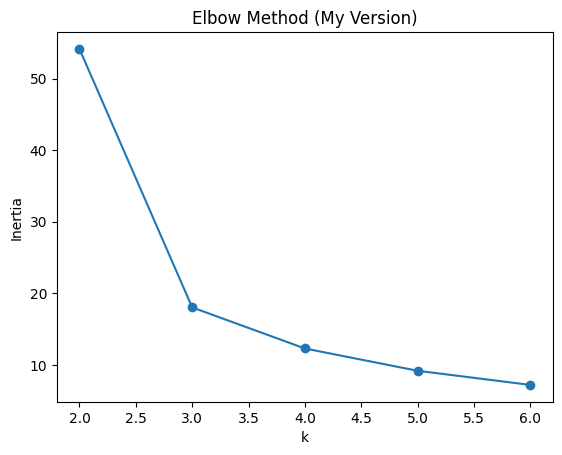

Silhouette Score: 0.5988016665822246


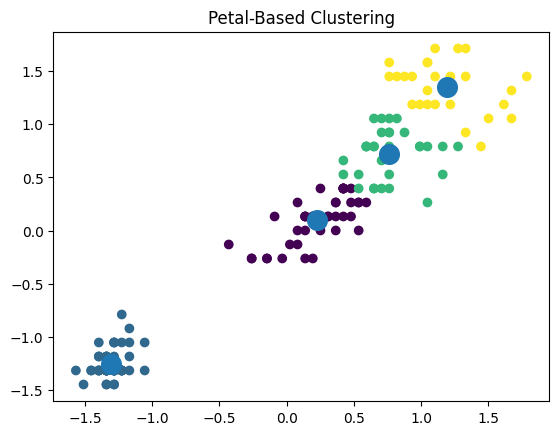

In [ ]:
# ImporImportt libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Load dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Use petal features only (my choice)
petal_data = df[['petal length (cm)', 'petal width (cm)']]

# Scale data
scaler = StandardScaler()
petal_scaled = scaler.fit_transform(petal_data)

# Elbow method
inertia = []
k_values = range(2, 7)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=30)
    model.fit(petal_scaled)
    inertia.append(model.inertia_)

plt.plot(k_values, inertia, marker='o')
plt.title('Elbow Method (My Version)')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.show()

# Apply KMeans (k=4)
kmeans = KMeans(n_clusters=4, random_state=30)
clusters = kmeans.fit_predict(petal_scaled)

# Evaluate
score = silhouette_score(petal_scaled, clusters)
print("Silhouette Score:", score)

# Plot
plt.scatter(petal_scaled[:,0], petal_scaled[:,1], c=clusters)
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            s=200)

plt.title('Petal-Based Clustering')
plt.show()

This project uses K-Means clustering on the Iris dataset.
I selected petal length and width because they show clearer grouping.
I also applied scaling and tested multiple k values to find the best clustering.
